# Digital Signal Processing Training Program 

![Texto Alternativo](images/V-CC_Color_Completa_TextoAzul.png)

### Dev by:
-   Elmer Pimentel Farias


# *OOK- Match-Zehnder Transmission*

![Texto Alternativo](images/transmission_fiber.png)


The block diagram above illustrates the fundamental steps for generating and transmitting an optical signal using the OOK (On-Off Keying) modulation format. To overcome the chirp limitations associated with direct modulation, this architecture uses **External Modulation**, separating the system into two main processing domains:

### 1. Electrical Domain
In this stage, the digital information is prepared and conditioned into an electrical signal format before interacting with the photonic components.
* **Data Source:** Generation of the binary digital information sequence (bits 0 and 1). In communication systems simulations, a pseudo-random bit sequence (PRBS) is frequently used.
* **Line Coder (NRZ Generator):** Responsible for mapping the logical bits into an electrical waveform in the time domain. The NRZ (Non-Return-to-Zero) format is the most common standard for this application, where the electrical pulse occupies the entire duration of the bit period.
* **RF Driver / Amplifier:** The raw electrical signal (baseband) needs to be amplified to reach the voltage swings required by the photonic modulator. This block amplifies the radio frequency signal and applies the appropriate **Bias voltage**, ensuring that the modulator operates at the correct point on its transfer curve.

### 2. Optical Domain
Here, the optical carrier is generated and receives the "imprint" of the electrical signal through interference phenomena.
* **CW Laser (Continuous Wave):** A laser diode (usually DFB type) that emits a continuous light wave ($P_{in}$), providing a carrier with a narrow wavelength, constant power, and high stability.
* **Mach-Zehnder Modulator (MZM):** The heart of the external modulation. Acting as a voltage-controlled interferometer, it receives the CW light and the signal from the RF Driver. The applied electrical voltage alters the refractive index in the modulator's arms (Pockels electro-optic effect), creating a phase difference. The recombination of this light results in constructive interference (Light = Bit 1) or destructive interference (No Light = Bit 0), thus generating the OOK optical signal at the output ($P_{out}$).

![Texto Alternativo](images/MZM.png)



* **Conditioning (Isolator/EDFA):** The final optical preparation stage that may include isolators (to prevent light reflections from returning to the laser cavity and causing instability) and Erbium-Doped Fiber Amplifiers (EDFA) to ensure the ideal launch power into the fiber.

### 3. Transmission Channel
* **Optical Fiber:** The physical propagation medium. The injected optical signal will be subject to the nonlinearities, attenuation, and chromatic dispersion inherent to the optical fiber during its path to the receiver.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from optic.comm.sources import bitSource
from optic.comm.modulation import modulateGray, grayMapping , demodulateGray
from optic.comm.metrics import bert, fastBERcalc
from optic.dsp.core import firFilter, pulseShape, upsample, pnorm, anorm, decimate 
from optic.utils import parameters, dBm2W 
from optic.models.devices import dac, adc
from optic.models.channels import awgn
from optic.plot import eyediagram
from optic.models.devices import mzm
from scipy.special import erfc
import optic.comm.modulation as mod
from numpy.random import normal
import pandas as pd


c:\Users\elmer.farias\anaconda3\Lib\site-packages\cupyx\jit\_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


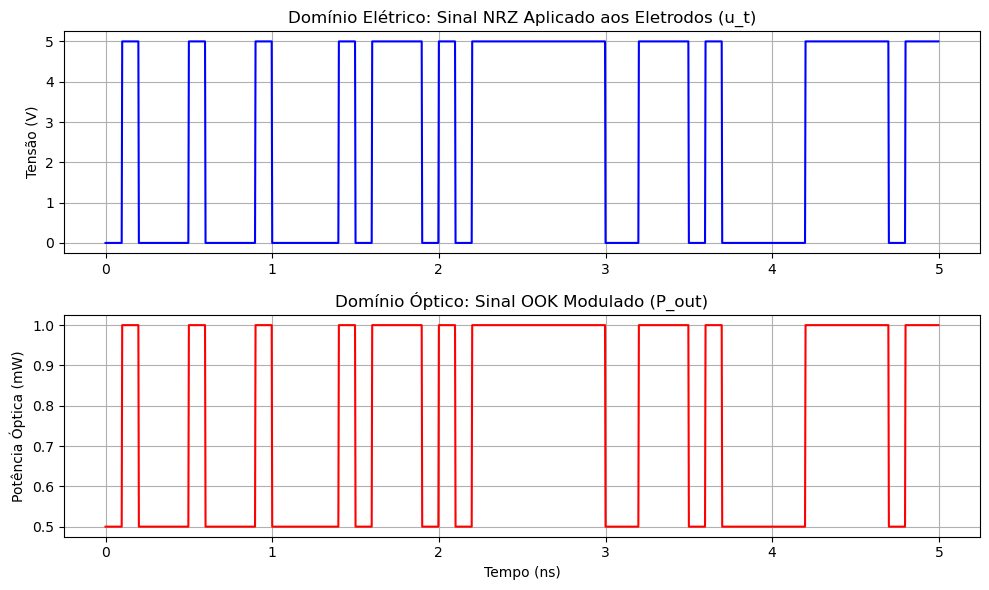

In [ ]:
# 1. Parâmetros de Simulação
Rs = 10e9           # Taxa de símbolos (10 GBaud)
SpS = 32            # Amostras por símbolo (resolução da simulação)
Ts = 1 / Rs         # Período do bit
Fa = Rs * SpS       # Frequência de amostragem
Ta = 1 / Fa         # Tempo de amostragem
Nbits = 50          # Número de bits para simular e visualizar

# 2. Domínio Elétrico: Fonte de Dados e Gerador NRZ
np.random.seed(42)
bits = np.random.randint(2, size=Nbits)

# Formatação NRZ: repetimos o valor de cada bit 'SpS' vezes
sinal_nrz = np.repeat(bits, SpS)

# Sincronização rigorosa do eixo do tempo com o tamanho do sinal.
# Isso garante que 'tempo.shape' seja exatamente igual a 'sinal_nrz.shape',
# evitando erros de dimensão durante a chamada do Matplotlib.
tempo = np.arange(len(sinal_nrz)) * Ta

# 3. Driver RF (Condicionamento de Tensão)

V_pi = 5.0                 # Tensão de meia-onda típica do MZM
V_bias = V_pi / 2          # Polarização no ponto de quadratura
V_rf_pico = V_pi           # Amplitude de pico-a-pico do sinal RF

# Mapeando os bits lógicos (0 e 1) para as tensões elétricas V(t)
u_t = V_bias + V_rf_pico * (sinal_nrz - 0.5)


# 4. Domínio Óptico: Laser CW e MZM

P_in_dBm = 0                               # Potência do laser CW em dBm
P_in_W = (10 ** (P_in_dBm / 10)) * 1e-3    # Conversão para Watts
Ai = np.sqrt(P_in_W)                       # Amplitude do campo óptico de entrada

# Modulação Externa usando o OptiCommPy
# O framework aplica a não-linearidade do interferômetro sobre o campo Ai
param_mzm = {'Vpi': V_pi}
E_out = mzm(Ai, u_t, param=param_mzm)

# Extraindo a Potência Óptica do campo elétrico gerado
P_out = np.abs(E_out)**2


fig, ax = plt.subplots(2, 1, figsize=(10, 6))

# Gráfico 1: Sinal elétrico de entrada
ax[0].plot(tempo * 1e9, u_t, color='blue', linewidth=1.5)
ax[0].set_title('Domínio Elétrico: Sinal NRZ Aplicado aos Eletrodos (u_t)')
ax[0].set_ylabel('Tensão (V)')
ax[0].grid(True)

# Gráfico 2: Sinal óptico de saída OOK (Sem amplificação)
ax[1].plot(tempo * 1e9, P_out * 1e3, color='red', linewidth=1.5)
ax[1].set_title('Domínio Óptico: Sinal OOK Modulado (P_out)')
ax[1].set_xlabel('Tempo (ns)')
ax[1].set_ylabel('Potência Óptica (mW)')
ax[1].grid(True)

plt.tight_layout()
plt.show()

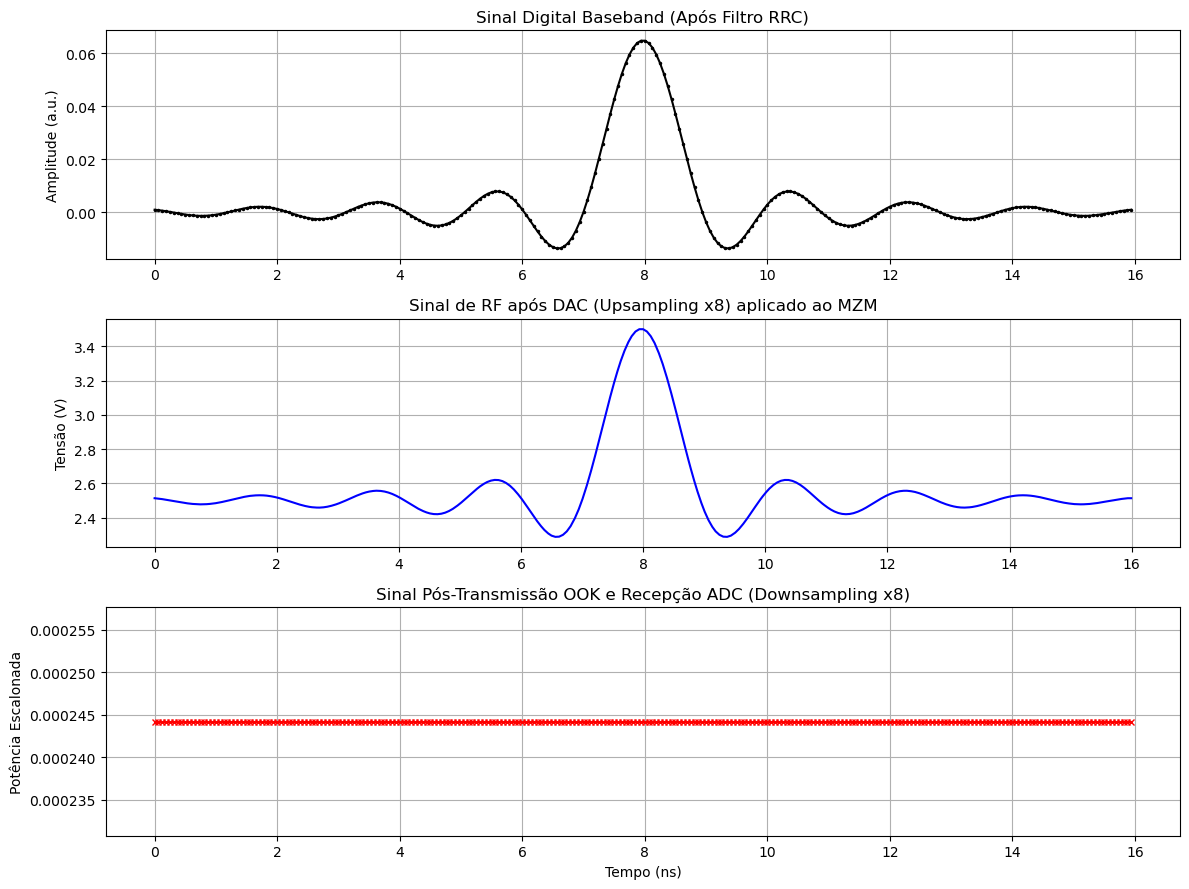

In [3]:
# --- INÍCIO DA SUA DECLARAÇÃO DE PARÂMETROS ---
# Rate Symbol
Rs = 10e8

# Sample Per Symbol
SpS = 16

# Sample Rate
Fa = Rs * SpS

# Sample Time
Ta = 1 / Fa

# Modulation Order
M = [2, 4, 16]

# Parameters for Bits Generation
paramBits = parameters()
paramBits.nBits = 10000
paramBits.mode = 'random'
paramBits.seed = 10

# Parameters for Pulse Shaping
paramPulse = parameters()
paramPulse.pulseType = 'rrc'
paramPulse.SpS = SpS

bits = bitSource(paramBits)
pulse = pulseShape(paramPulse)

t = np.arange(0, pulse.size) * Ta

# Parameters for DAC
j = 8
paramDAC = parameters()
paramDAC.inFs = Fa
paramDAC.outFs = j * Fa
paramDAC.nBits = 12
paramDAC.ENOB = 12
paramDAC.Vpp = 2
paramDAC.AIF = False

# Parameters for ADC
paramADC = parameters()
paramADC.inFs = j * Fa 
paramADC.outFs = Fa 
paramADC.nBits = 12 
paramADC.ENOB = 12 
paramADC.Vpp = 2 
paramADC.AIF = False 

# Parameters for Decimation
paramDec = parameters()
paramDec.SpSin = SpS 
paramDec.SpSout = 1 
# --- FIM DA SUA DECLARAÇÃO DE PARÂMETROS ---


# ==========================================
# 2. Conversão Digital-Analógica (DAC)
# ==========================================
# O DAC fará o oversampling (fator j) do sinal baseband
signal_dac = dac(pulse, paramDAC)

# Sincronização rigorosa do eixo de tempo para a nova taxa de amostragem do DAC
# Isso evita o erro de dimensões incompatíveis (shapes) na hora do plot
t_dac = np.arange(0, signal_dac.size) * (1 / paramDAC.outFs)


# ==========================================
# 3. Driver RF e Domínio Óptico (MZM)
# ==========================================
V_pi = 5.0
V_bias = V_pi / 2

# Condicionamento do sinal bipolar RRC para o Driver RF do MZM
# Ajustamos a amplitude para bater com o Vpp=2 e centralizamos no V_bias
u_t = V_bias + (signal_dac / np.max(np.abs(signal_dac))) * (paramDAC.Vpp / 2)

P_in_dBm = 0
P_in_W = (10 ** (P_in_dBm / 10)) * 1e-3
Ai = np.sqrt(P_in_W)

# Modulação Externa
param_mzm = {'Vpi': V_pi}
E_out = mzm(Ai, u_t, param=param_mzm)

# Extração da potência óptica na saída do modulador
P_out = np.abs(E_out)**2


# ==========================================
# 4. Recepção e ADC
# ==========================================
# O ADC converte o sinal óptico de volta, faz a quantização e o downsampling (fator j)
# retornando o sinal para a taxa original Fa.
signal_adc = adc(P_out, paramADC)

# Sincronização do eixo de tempo para o sinal após o downsampling
t_adc = np.arange(0, signal_adc.size) * (1 / paramADC.outFs)


# ==========================================
# 5. Visualização Sincronizada dos Arrays
# ==========================================
fig, ax = plt.subplots(3, 1, figsize=(12, 9))

# Selecionamos uma janela limite para facilitar a visualização 
limite_symb = 40
limite_idx_adc = limite_symb * SpS
limite_idx_dac = limite_symb * SpS * j

# Gráfico 1: Sinal baseband original (Saída do gerador RRC)
ax[0].plot(t[:limite_idx_adc] * 1e9, pulse[:limite_idx_adc], color='black', marker='.', ms=3)
ax[0].set_title('Sinal Digital Baseband (Após Filtro RRC)')
ax[0].set_ylabel('Amplitude (a.u.)')
ax[0].grid(True)

# Gráfico 2: Sinal elétrico de alta taxa (Saída do DAC)
ax[1].plot(t_dac[:limite_idx_dac] * 1e9, u_t[:limite_idx_dac], color='blue')
ax[1].set_title(f'Sinal de RF após DAC (Upsampling x{j}) aplicado ao MZM')
ax[1].set_ylabel('Tensão (V)')
ax[1].grid(True)

# Gráfico 3: Sinal recuperado após o fotodiodo e o ADC
ax[2].plot(t_adc[:limite_idx_adc] * 1e9, signal_adc[:limite_idx_adc], color='red', marker='x', ms=4)
ax[2].set_title(f'Sinal Pós-Transmissão OOK e Recepção ADC (Downsampling x{j})')
ax[2].set_xlabel('Tempo (ns)')
ax[2].set_ylabel('Potência Escalonada')
ax[2].grid(True)

plt.tight_layout()
plt.show()